In [5]:
# ============================================================
# 08 — Batch 2 Inventory
# ============================================================

from pathlib import Path
import sys
import os
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Project root
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().resolve()

# If notebook is being run from notebooks/, move to project root
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Make src importable
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:")
print(PROJECT_ROOT)

# ------------------------------------------------------------
# Directories
# ------------------------------------------------------------

DATA_DIR = PROJECT_ROOT / "data"

RAW_CT_DIR = DATA_DIR / "raw_ct"
LABELS_DIR = DATA_DIR / "labels"

AUTO_LABEL_DIR = LABELS_DIR / "Automatic_Labels"
MANUAL_LABEL_DIR = LABELS_DIR / "Manual_Labels"

PROCESSED_DIR = DATA_DIR / "processed"

print("\nDirectories:")
print("RAW CT       :", RAW_CT_DIR)
print("Auto labels  :", AUTO_LABEL_DIR)
print("Manual labels:", MANUAL_LABEL_DIR)
print("Processed    :", PROCESSED_DIR)

Project root:
D:\Pancreatic_Cancer_Thesis

Directories:
RAW CT       : D:\Pancreatic_Cancer_Thesis\data\raw_ct
Auto labels  : D:\Pancreatic_Cancer_Thesis\data\labels\Automatic_Labels
Manual labels: D:\Pancreatic_Cancer_Thesis\data\labels\Manual_Labels
Processed    : D:\Pancreatic_Cancer_Thesis\data\processed


In [6]:
# ============================================================
# Directory existence check
# ============================================================

directories = {
    "raw_ct": RAW_CT_DIR,
    "automatic_labels": AUTO_LABEL_DIR,
    "manual_labels": MANUAL_LABEL_DIR,
    "processed": PROCESSED_DIR,
}

print("=" * 60)
print("DIRECTORY CHECK")
print("=" * 60)

for name, path in directories.items():
    print(f"{name:20s}: {path}")
    print(f"{'exists':20s}: {path.exists()}")
    print()

DIRECTORY CHECK
raw_ct              : D:\Pancreatic_Cancer_Thesis\data\raw_ct
exists              : True

automatic_labels    : D:\Pancreatic_Cancer_Thesis\data\labels\Automatic_Labels
exists              : True

manual_labels       : D:\Pancreatic_Cancer_Thesis\data\labels\Manual_Labels
exists              : True

processed           : D:\Pancreatic_Cancer_Thesis\data\processed
exists              : True



In [7]:
# ============================================================
# Raw CT inventory
# ============================================================

ct_files = sorted(RAW_CT_DIR.glob("*.nii.gz"))

raw_ids = []

for path in ct_files:
    filename = path.name

    if filename.endswith("_0000.nii.gz"):
        study_id = filename[:-len("_0000.nii.gz")]
        raw_ids.append(study_id)

print("=" * 60)
print("RAW CT INVENTORY")
print("=" * 60)

print(f"CT files found : {len(ct_files)}")
print(f"Study IDs      : {len(raw_ids)}")

print("\nFirst 20 study IDs:")
for study_id in raw_ids[:20]:
    print(study_id)

RAW CT INVENTORY
CT files found : 566
Study IDs      : 566

First 20 study IDs:
100546_00001
100547_00001
100548_00001
100549_00001
100550_00001
100551_00001
100552_00001
100553_00001
100554_00001
100555_00001
100556_00001
100557_00001
100558_00001
100559_00001
100560_00001
100561_00001
100562_00001
100563_00001
100564_00001
100565_00001


In [8]:
import sys
from pathlib import Path

sys.path.append("D:/Pancreatic_Cancer_Thesis")

from src import preprocessing as prep

raw_cases = prep.list_ct_cases()

print("Total CT cases found:", len(raw_cases))
print("\nFirst 20:")
for case in raw_cases[:20]:
    print(case)

Total CT cases found: 566

First 20:
100546_00001
100547_00001
100548_00001
100549_00001
100550_00001
100551_00001
100552_00001
100553_00001
100554_00001
100555_00001
100556_00001
100557_00001
100558_00001
100559_00001
100560_00001
100561_00001
100562_00001
100563_00001
100564_00001
100565_00001


In [9]:
# ============================================================
# Separate retained Batch 1 case from newly downloaded cases
# ============================================================

RETAINED_BATCH1_ID = "100433_00001"

raw_id_set = set(raw_ids)

if RETAINED_BATCH1_ID in raw_id_set:
    batch1_retained = {RETAINED_BATCH1_ID}
else:
    batch1_retained = set()

batch2_ids = raw_id_set - batch1_retained

print("=" * 60)
print("BATCH SEPARATION")
print("=" * 60)

print("Retained Batch 1 cases :", len(batch1_retained))
print("Batch 2 candidates     :", len(batch2_ids))
print("Total raw CT cases     :", len(raw_id_set))

if batch1_retained:
    print("\nRetained Batch 1 case:")
    print(RETAINED_BATCH1_ID)

BATCH SEPARATION
Retained Batch 1 cases : 0
Batch 2 candidates     : 566
Total raw CT cases     : 566


In [10]:
# ============================================================
# Duplicate study ID check
# ============================================================

from collections import Counter

id_counts = Counter(raw_ids)

duplicate_ids = sorted(
    study_id
    for study_id, count in id_counts.items()
    if count > 1
)

print("=" * 60)
print("DUPLICATE STUDY ID CHECK")
print("=" * 60)

print("Duplicate study IDs:", len(duplicate_ids))

if duplicate_ids:
    print("\nDuplicates:")
    for study_id in duplicate_ids:
        print(study_id)
else:
    print("✓ No duplicate study IDs found.")

DUPLICATE STUDY ID CHECK
Duplicate study IDs: 0
✓ No duplicate study IDs found.


In [11]:
# ============================================================
# Label inventory
# ============================================================

def extract_study_id_from_label(path):
    """
    Extract study ID from a label filename.

    Expected:
        100546_00001.nii.gz
    """

    name = path.name

    if name.endswith(".nii.gz"):
        return name[:-7]

    return path.stem


auto_label_files = sorted(AUTO_LABEL_DIR.glob("*.nii.gz"))
manual_label_files = sorted(MANUAL_LABEL_DIR.glob("*.nii.gz"))

auto_ids = {
    extract_study_id_from_label(path)
    for path in auto_label_files
}

manual_ids = {
    extract_study_id_from_label(path)
    for path in manual_label_files
}

print("=" * 60)
print("LABEL INVENTORY")
print("=" * 60)

print("Automatic label files :", len(auto_label_files))
print("Automatic study IDs   :", len(auto_ids))

print("Manual label files    :", len(manual_label_files))
print("Manual study IDs      :", len(manual_ids))

LABEL INVENTORY
Automatic label files : 1758
Automatic study IDs   : 1758
Manual label files    : 482
Manual study IDs      : 482


In [12]:
# ============================================================
# Batch 2 CT ↔ Automatic Label comparison
# ============================================================

missing_auto_labels = sorted(
    batch2_ids - auto_ids
)

extra_auto_labels = sorted(
    auto_ids - batch2_ids - batch1_retained
)

print("=" * 60)
print("BATCH 2 ↔ AUTOMATIC LABELS")
print("=" * 60)

print("Batch 2 CT cases          :", len(batch2_ids))
print("Batch 2 missing auto mask :", len(missing_auto_labels))
print("Extra automatic labels    :", len(extra_auto_labels))

if missing_auto_labels:
    print("\nMissing automatic labels:")
    for study_id in missing_auto_labels[:100]:
        print(study_id)

if extra_auto_labels:
    print("\nExtra automatic labels:")
    for study_id in extra_auto_labels[:100]:
        print(study_id)

BATCH 2 ↔ AUTOMATIC LABELS
Batch 2 CT cases          : 566
Batch 2 missing auto mask : 122
Extra automatic labels    : 1314

Missing automatic labels:
100555_00001
100557_00001
100563_00001
100564_00001
100565_00001
100576_00001
100583_00001
100588_00001
100589_00001
100598_00001
100599_00001
100602_00001
100608_00001
100611_00001
100613_00001
100617_00001
100623_00001
100629_00001
100634_00001
100645_00001
100649_00001
100652_00001
100655_00001
100658_00001
100664_00001
100665_00001
100667_00001
100668_00001
100673_00001
100679_00001
100684_00001
100687_00001
100690_00001
100691_00001
100695_00001
100698_00001
100705_00001
100711_00001
100712_00001
100713_00001
100714_00001
100715_00001
100722_00001
100725_00001
100727_00001
100728_00001
100732_00001
100733_00001
100734_00001
100743_00001
100755_00001
100756_00001
100775_00001
100776_00001
100780_00001
100789_00001
100790_00001
100795_00001
100796_00001
100799_00001
100803_00001
100809_00001
100815_00001
100820_00001
100824_00001
1008

In [13]:
# ============================================================
# Batch 2 CT ↔ Manual Label comparison
# ============================================================

missing_manual_labels = sorted(
    batch2_ids - manual_ids
)

extra_manual_labels = sorted(
    manual_ids - batch2_ids - batch1_retained
)

print("=" * 60)
print("BATCH 2 ↔ MANUAL LABELS")
print("=" * 60)

print("Batch 2 CT cases          :", len(batch2_ids))
print("Batch 2 missing manual   :", len(missing_manual_labels))
print("Extra manual labels      :", len(extra_manual_labels))

if missing_manual_labels:
    print("\nMissing manual labels:")
    for study_id in missing_manual_labels[:100]:
        print(study_id)

if extra_manual_labels:
    print("\nExtra manual labels:")
    for study_id in extra_manual_labels[:100]:
        print(study_id)

BATCH 2 ↔ MANUAL LABELS
Batch 2 CT cases          : 566
Batch 2 missing manual   : 444
Extra manual labels      : 360

Missing manual labels:
100546_00001
100547_00001
100548_00001
100549_00001
100550_00001
100551_00001
100552_00001
100553_00001
100554_00001
100556_00001
100558_00001
100559_00001
100560_00001
100561_00001
100562_00001
100566_00001
100567_00001
100568_00001
100569_00001
100570_00001
100571_00001
100572_00001
100573_00001
100574_00001
100575_00001
100577_00001
100578_00001
100579_00001
100580_00001
100581_00001
100582_00001
100584_00001
100585_00001
100586_00001
100587_00001
100590_00001
100591_00001
100592_00001
100593_00001
100594_00001
100595_00001
100596_00001
100597_00001
100600_00001
100601_00001
100603_00001
100604_00001
100605_00001
100606_00001
100607_00001
100609_00001
100610_00001
100612_00001
100614_00001
100615_00001
100616_00001
100618_00001
100619_00001
100620_00001
100621_00001
100622_00001
100624_00001
100625_00001
100626_00001
100627_00001
100628_00001


In [14]:
# ============================================================
# Compare against processed metadata
# ============================================================

metadata_path = PROCESSED_DIR / "metadata.csv"

if metadata_path.exists():

    metadata = pd.read_csv(metadata_path)

    metadata_ids = set(
        metadata["study_id"]
        .astype(str)
        .str.strip()
    )

    already_processed_batch2 = sorted(
        batch2_ids & metadata_ids
    )

else:

    metadata = None
    metadata_ids = set()
    already_processed_batch2 = []

print("=" * 60)
print("PROCESSED DATASET COMPARISON")
print("=" * 60)

print("Metadata file exists :", metadata_path.exists())
print("Processed cases      :", len(metadata_ids))
print("Batch 2 already processed:", len(already_processed_batch2))

if already_processed_batch2:
    print("\nAlready processed Batch 2 cases:")
    for study_id in already_processed_batch2:
        print(study_id)

PROCESSED DATASET COMPARISON
Metadata file exists : True
Processed cases      : 557
Batch 2 already processed: 0


In [15]:
# ============================================================
# Build Batch 2 inventory table
# ============================================================

batch2_inventory = pd.DataFrame({
    "study_id": sorted(batch2_ids)
})

batch2_inventory["ct_exists"] = batch2_inventory["study_id"].isin(
    raw_id_set
)

batch2_inventory["automatic_label_exists"] = (
    batch2_inventory["study_id"].isin(auto_ids)
)

batch2_inventory["manual_label_exists"] = (
    batch2_inventory["study_id"].isin(manual_ids)
)

batch2_inventory["already_processed"] = (
    batch2_inventory["study_id"].isin(metadata_ids)
)

batch2_inventory["ready_for_inspection"] = (
    batch2_inventory["ct_exists"]
    & batch2_inventory["automatic_label_exists"]
)

batch2_inventory.head(20)

,study_id,ct_exists,automatic_label_exists,manual_label_exists,already_processed,ready_for_inspection
0,100546_00001,True,True,False,False,True
1,100547_00001,True,True,False,False,True
2,100548_00001,True,True,False,False,True
3,100549_00001,True,True,False,False,True
4,100550_00001,True,True,False,False,True
5,100551_00001,True,True,False,False,True
6,100552_00001,True,True,False,False,True
7,100553_00001,True,True,False,False,True
8,100554_00001,True,True,False,False,True
9,100555_00001,True,False,True,False,False


In [16]:
# ============================================================
# Batch 2 inventory summary
# ============================================================

print("=" * 60)
print("BATCH 2 INVENTORY SUMMARY")
print("=" * 60)

total_batch2 = len(batch2_inventory)

ct_count = batch2_inventory["ct_exists"].sum()
auto_count = batch2_inventory["automatic_label_exists"].sum()
manual_count = batch2_inventory["manual_label_exists"].sum()
processed_count = batch2_inventory["already_processed"].sum()
ready_count = batch2_inventory["ready_for_inspection"].sum()

print(f"Batch 2 CT cases              : {total_batch2}")
print(f"CT files present              : {ct_count}")
print(f"Automatic labels present     : {auto_count}")
print(f"Manual labels present        : {manual_count}")
print(f"Already processed            : {processed_count}")
print(f"CT + automatic label pairs   : {ready_count}")

BATCH 2 INVENTORY SUMMARY
Batch 2 CT cases              : 566
CT files present              : 566
Automatic labels present     : 444
Manual labels present        : 122
Already processed            : 0
CT + automatic label pairs   : 444


In [17]:
# ============================================================
# Label Availability Classification
# ============================================================

batch2_inventory["has_any_label"] = (
    batch2_inventory["automatic_label_exists"]
    | batch2_inventory["manual_label_exists"]
)

batch2_inventory["has_both_labels"] = (
    batch2_inventory["automatic_label_exists"]
    & batch2_inventory["manual_label_exists"]
)

batch2_inventory["has_automatic_only"] = (
    batch2_inventory["automatic_label_exists"]
    & ~batch2_inventory["manual_label_exists"]
)

batch2_inventory["has_manual_only"] = (
    batch2_inventory["manual_label_exists"]
    & ~batch2_inventory["automatic_label_exists"]
)

batch2_inventory["has_no_label"] = (
    ~batch2_inventory["automatic_label_exists"]
    & ~batch2_inventory["manual_label_exists"]
)

print("=" * 60)
print("BATCH 2 LABEL AVAILABILITY")
print("=" * 60)

print(f"Total cases       : {len(batch2_inventory)}")
print(f"Any label         : {batch2_inventory['has_any_label'].sum()}")
print(f"Both labels       : {batch2_inventory['has_both_labels'].sum()}")
print(f"Automatic only    : {batch2_inventory['has_automatic_only'].sum()}")
print(f"Manual only       : {batch2_inventory['has_manual_only'].sum()}")
print(f"No label          : {batch2_inventory['has_no_label'].sum()}")

BATCH 2 LABEL AVAILABILITY
Total cases       : 566
Any label         : 566
Both labels       : 0
Automatic only    : 444
Manual only       : 122
No label          : 0


In [18]:
# ============================================================
# Problematic Batch 2 Cases
# ============================================================

print("=" * 60)
print("BATCH 2 — PROBLEMATIC CASES")
print("=" * 60)

# ------------------------------------------------------------
# Check that the expected inventory columns exist
# ------------------------------------------------------------

required_columns = [
    "study_id",
    "ct_exists",
    "automatic_label_exists",
    "manual_label_exists",
]

missing_columns = [
    col for col in required_columns
    if col not in batch2_inventory.columns
]

if missing_columns:
    raise KeyError(
        f"Missing expected columns in batch2_inventory: {missing_columns}"
    )

# ------------------------------------------------------------
# Identify cases with any missing CT or segmentation label
# ------------------------------------------------------------

problems = batch2_inventory[
    (~batch2_inventory["ct_exists"])
    | (~batch2_inventory["automatic_label_exists"])
    | (~batch2_inventory["manual_label_exists"])
].copy()

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

total_problematic = len(problems)

missing_ct = (~problems["ct_exists"]).sum()
missing_automatic = (~problems["automatic_label_exists"]).sum()
missing_manual = (~problems["manual_label_exists"]).sum()

print(f"Total Batch 2 cases        : {len(batch2_inventory)}")
print(f"Problematic cases          : {total_problematic}")
print()
print(f"Missing CT                 : {missing_ct}")
print(f"Missing automatic labels   : {missing_automatic}")
print(f"Missing manual labels      : {missing_manual}")
print("=" * 60)

# ------------------------------------------------------------
# Display problematic cases
# ------------------------------------------------------------

if total_problematic > 0:

    print("\nPotentially problematic cases:")
    print()

    display(
        problems[
            [
                "study_id",
                "ct_exists",
                "automatic_label_exists",
                "manual_label_exists",
            ]
        ].sort_values("study_id")
    )

else:

    print("✓ No missing CT or label entries detected.")

BATCH 2 — PROBLEMATIC CASES
Total Batch 2 cases        : 566
Problematic cases          : 566

Missing CT                 : 0
Missing automatic labels   : 122
Missing manual labels      : 444

Potentially problematic cases:



,study_id,ct_exists,automatic_label_exists,manual_label_exists
0,100546_00001,True,True,False
1,100547_00001,True,True,False
2,100548_00001,True,True,False
3,100549_00001,True,True,False
4,100550_00001,True,True,False
...,...,...,...,...
561,101107_00001,True,True,False
562,101108_00001,True,True,False
563,101109_00001,True,True,False
564,101110_00001,True,True,False


In [19]:
# ============================================================
# File size inspection
# ============================================================

size_records = []

for study_id in sorted(batch2_ids):

    ct_path = RAW_CT_DIR / f"{study_id}_0000.nii.gz"

    if ct_path.exists():

        size_mb = ct_path.stat().st_size / (1024 ** 2)

        size_records.append({
            "study_id": study_id,
            "ct_size_mb": size_mb,
            "ct_path": str(ct_path),
        })

size_df = pd.DataFrame(size_records)

print("=" * 60)
print("CT FILE SIZE SUMMARY")
print("=" * 60)

print(f"Files inspected: {len(size_df)}")

if not size_df.empty:

    print("\nMinimum size:")
    print(f"{size_df['ct_size_mb'].min():.2f} MB")

    print("\nMaximum size:")
    print(f"{size_df['ct_size_mb'].max():.2f} MB")

    print("\nMedian size:")
    print(f"{size_df['ct_size_mb'].median():.2f} MB")

    print("\nSmallest 10 files:")
    display(
        size_df
        .sort_values("ct_size_mb")
        .head(10)
    )

CT FILE SIZE SUMMARY
Files inspected: 566

Minimum size:
11.59 MB

Maximum size:
431.64 MB

Median size:
65.83 MB

Smallest 10 files:


,study_id,ct_size_mb,ct_path
256,100802_00001,11.586982,D:\Pancreatic_Cancer_Thesis\data\raw_ct\100802...
247,100793_00001,12.737247,D:\Pancreatic_Cancer_Thesis\data\raw_ct\100793...
188,100734_00001,13.208615,D:\Pancreatic_Cancer_Thesis\data\raw_ct\100734...
216,100762_00001,13.579547,D:\Pancreatic_Cancer_Thesis\data\raw_ct\100762...
367,100913_00001,14.847137,D:\Pancreatic_Cancer_Thesis\data\raw_ct\100913...
510,101056_00001,15.006021,D:\Pancreatic_Cancer_Thesis\data\raw_ct\101056...
453,100999_00001,15.679770,D:\Pancreatic_Cancer_Thesis\data\raw_ct\100999...
289,100835_00001,17.290797,D:\Pancreatic_Cancer_Thesis\data\raw_ct\100835...
418,100964_00001,17.523035,D:\Pancreatic_Cancer_Thesis\data\raw_ct\100964...
359,100905_00001,17.810259,D:\Pancreatic_Cancer_Thesis\data\raw_ct\100905...


In [20]:
# ============================================================
# Random CT readability test
# ============================================================

import random
import SimpleITK as sitk

RANDOM_SEED = 42
SAMPLE_SIZE = 5

random.seed(RANDOM_SEED)

sample_ids = random.sample(
    sorted(batch2_ids),
    min(SAMPLE_SIZE, len(batch2_ids))
)

read_results = []

print("=" * 60)
print("RANDOM CT READABILITY TEST")
print("=" * 60)

for study_id in sample_ids:

    ct_path = RAW_CT_DIR / f"{study_id}_0000.nii.gz"

    result = {
        "study_id": study_id,
        "readable": False,
        "shape": None,
        "spacing": None,
        "dtype": None,
        "error": None,
    }

    try:

        image = sitk.ReadImage(str(ct_path))
        array = sitk.GetArrayFromImage(image)

        result["readable"] = True
        result["shape"] = tuple(array.shape)
        result["spacing"] = tuple(image.GetSpacing())
        result["dtype"] = str(array.dtype)

        print(f"✓ {study_id}")
        print(f"  Shape   : {array.shape}")
        print(f"  Spacing : {image.GetSpacing()}")
        print(f"  Dtype   : {array.dtype}")

    except Exception as e:

        result["error"] = str(e)

        print(f"✗ {study_id}")
        print(f"  Error: {e}")

    read_results.append(result)

read_df = pd.DataFrame(read_results)

print("\nReadability summary:")
display(read_df)

RANDOM CT READABILITY TEST
✓ 100660_00001
  Shape   : (402, 512, 512)
  Spacing : (0.623046875, 0.623046875, 1.5)
  Dtype   : int16
✓ 100571_00001
  Shape   : (168, 512, 512)
  Spacing : (0.80078125, 0.80078125, 4.0)
  Dtype   : int32
✓ 100827_00001
  Shape   : (301, 512, 512)
  Spacing : (0.628000020980835, 0.628000020980835, 0.800000011920929)
  Dtype   : int16
✓ 100796_00001
  Shape   : (105, 512, 512)
  Spacing : (0.75, 0.75, 2.5)
  Dtype   : float32
✓ 100774_00001
  Shape   : (96, 512, 512)
  Spacing : (0.9570000171661377, 0.9570000171661377, 2.4000000953674316)
  Dtype   : int16

Readability summary:


,study_id,readable,shape,spacing,dtype,error
0,100660_00001,True,"(402, 512, 512)","(0.623046875, 0.623046875, 1.5)",int16,None
1,100571_00001,True,"(168, 512, 512)","(0.80078125, 0.80078125, 4.0)",int32,None
2,100827_00001,True,"(301, 512, 512)","(0.628000020980835, 0.628000020980835, 0.80000...",int16,None
3,100796_00001,True,"(105, 512, 512)","(0.75, 0.75, 2.5)",float32,None
4,100774_00001,True,"(96, 512, 512)","(0.9570000171661377, 0.9570000171661377, 2.400...",int16,None


In [21]:
# ============================================================
# Random automatic-label readability test
# ============================================================

mask_results = []

print("=" * 60)
print("RANDOM AUTOMATIC MASK READABILITY TEST")
print("=" * 60)

for study_id in sample_ids:

    mask_path = AUTO_LABEL_DIR / f"{study_id}.nii.gz"

    result = {
        "study_id": study_id,
        "mask_exists": mask_path.exists(),
        "readable": False,
        "shape": None,
        "spacing": None,
        "dtype": None,
        "labels": None,
        "error": None,
    }

    if not mask_path.exists():

        result["error"] = "Mask file does not exist"

        print(f"✗ {study_id}: mask missing")

        mask_results.append(result)
        continue

    try:

        image = sitk.ReadImage(str(mask_path))
        array = sitk.GetArrayFromImage(image)

        result["readable"] = True
        result["shape"] = tuple(array.shape)
        result["spacing"] = tuple(image.GetSpacing())
        result["dtype"] = str(array.dtype)

        unique_labels = np.unique(array)

        # Avoid dumping huge arrays
        result["labels"] = unique_labels.tolist()

        print(f"✓ {study_id}")
        print(f"  Shape   : {array.shape}")
        print(f"  Spacing : {image.GetSpacing()}")
        print(f"  Dtype   : {array.dtype}")
        print(f"  Labels  : {unique_labels}")

    except Exception as e:

        result["error"] = str(e)

        print(f"✗ {study_id}")
        print(f"  Error: {e}")

    mask_results.append(result)

mask_df = pd.DataFrame(mask_results)

print("\nMask readability summary:")
display(mask_df)

RANDOM AUTOMATIC MASK READABILITY TEST
✓ 100660_00001
  Shape   : (402, 512, 512)
  Spacing : (0.623046875, 0.623046875, 1.5)
  Dtype   : float64
  Labels  : [0. 2. 3. 4. 6.]
✓ 100571_00001
  Shape   : (168, 512, 512)
  Spacing : (0.80078125, 0.80078125, 4.0)
  Dtype   : float64
  Labels  : [0. 2. 3. 4. 6.]
✓ 100827_00001
  Shape   : (301, 512, 512)
  Spacing : (0.628000020980835, 0.628000020980835, 0.800000011920929)
  Dtype   : float64
  Labels  : [0. 2. 3. 4. 5. 6.]
✗ 100796_00001: mask missing
✓ 100774_00001
  Shape   : (96, 512, 512)
  Spacing : (0.9570000171661377, 0.9570000171661377, 2.4000000953674316)
  Dtype   : float64
  Labels  : [0. 2. 3. 4. 6.]

Mask readability summary:


,study_id,mask_exists,readable,shape,spacing,dtype,labels,error
0,100660_00001,True,True,"(402, 512, 512)","(0.623046875, 0.623046875, 1.5)",float64,"[0.0, 2.0, 3.0, 4.0, 6.0]",NaN
1,100571_00001,True,True,"(168, 512, 512)","(0.80078125, 0.80078125, 4.0)",float64,"[0.0, 2.0, 3.0, 4.0, 6.0]",NaN
2,100827_00001,True,True,"(301, 512, 512)","(0.628000020980835, 0.628000020980835, 0.80000...",float64,"[0.0, 2.0, 3.0, 4.0, 5.0, 6.0]",NaN
3,100796_00001,False,False,None,None,NaN,None,Mask file does not exist
4,100774_00001,True,True,"(96, 512, 512)","(0.9570000171661377, 0.9570000171661377, 2.400...",float64,"[0.0, 2.0, 3.0, 4.0, 6.0]",NaN


In [22]:
# ============================================================
# CT ↔ mask geometry comparison
# ============================================================

geometry_results = []

print("=" * 60)
print("CT ↔ MASK GEOMETRY CHECK")
print("=" * 60)

for study_id in sample_ids:

    ct_path = RAW_CT_DIR / f"{study_id}_0000.nii.gz"
    mask_path = AUTO_LABEL_DIR / f"{study_id}.nii.gz"

    result = {
        "study_id": study_id,
        "ct_shape": None,
        "mask_shape": None,
        "shape_match": False,
        "ct_spacing": None,
        "mask_spacing": None,
        "spacing_match": False,
        "ct_origin": None,
        "mask_origin": None,
        "origin_match": False,
        "ct_direction": None,
        "mask_direction": None,
        "direction_match": False,
        "error": None,
    }

    try:

        ct_image = sitk.ReadImage(str(ct_path))
        mask_image = sitk.ReadImage(str(mask_path))

        ct_array = sitk.GetArrayFromImage(ct_image)
        mask_array = sitk.GetArrayFromImage(mask_image)

        result["ct_shape"] = tuple(ct_array.shape)
        result["mask_shape"] = tuple(mask_array.shape)

        result["shape_match"] = (
            ct_array.shape == mask_array.shape
        )

        result["ct_spacing"] = tuple(
            round(x, 6) for x in ct_image.GetSpacing()
        )

        result["mask_spacing"] = tuple(
            round(x, 6) for x in mask_image.GetSpacing()
        )

        result["spacing_match"] = np.allclose(
            ct_image.GetSpacing(),
            mask_image.GetSpacing(),
            atol=1e-5,
        )

        result["ct_origin"] = tuple(
            round(x, 4) for x in ct_image.GetOrigin()
        )

        result["mask_origin"] = tuple(
            round(x, 4) for x in mask_image.GetOrigin()
        )

        result["origin_match"] = np.allclose(
            ct_image.GetOrigin(),
            mask_image.GetOrigin(),
            atol=1e-4,
        )

        result["ct_direction"] = tuple(
            round(x, 4) for x in ct_image.GetDirection()
        )

        result["mask_direction"] = tuple(
            round(x, 4) for x in mask_image.GetDirection()
        )

        result["direction_match"] = np.allclose(
            ct_image.GetDirection(),
            mask_image.GetDirection(),
            atol=1e-4,
        )

    except Exception as e:

        result["error"] = str(e)

    geometry_results.append(result)

geometry_df = pd.DataFrame(geometry_results)

display(geometry_df)

CT ↔ MASK GEOMETRY CHECK


,study_id,ct_shape,mask_shape,shape_match,ct_spacing,mask_spacing,spacing_match,ct_origin,mask_origin,origin_match,ct_direction,mask_direction,direction_match,error
0,100660_00001,"(402, 512, 512)","(402, 512, 512)",True,"(0.623047, 0.623047, 1.5)","(0.623047, 0.623047, 1.5)",True,"(-156.1885, -327.6885, 960.0)","(-156.1885, -327.6885, 960.0)",True,"(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)","(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)",True,NaN
1,100571_00001,"(168, 512, 512)","(168, 512, 512)",True,"(0.800781, 0.800781, 4.0)","(0.800781, 0.800781, 4.0)",True,"(-204.5996, -383.5996, -764.5)","(-204.5996, -383.5996, -764.5)",True,"(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)","(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)",True,NaN
2,100827_00001,"(301, 512, 512)","(301, 512, 512)",True,"(0.628, 0.628, 0.8)","(0.628, 0.628, 0.8)",True,"(-160.6231, -137.1856, 1556.0)","(-160.6231, -137.1856, 1556.0)",True,"(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)","(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)",True,NaN
3,100796_00001,None,None,False,None,None,False,None,None,False,None,None,False,Exception thrown in SimpleITK ImageFileReader_...
4,100774_00001,"(96, 512, 512)","(96, 512, 512)",True,"(0.957, 0.957, 2.4)","(0.957, 0.957, 2.4)",True,"(-243.6618, -244.6384, 1650.5)","(-243.6618, -244.6384, 1650.5)",True,"(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)","(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)",True,NaN


In [23]:
# ============================================================
# FINAL BATCH 2 INVENTORY REPORT
# ============================================================

print("\n")
print("=" * 60)
print("FINAL BATCH 2 INVENTORY REPORT")
print("=" * 60)

print(f"Raw CT files total              : {len(raw_id_set)}")
print(f"Retained Batch 1 CT             : {len(batch1_retained)}")
print(f"Batch 2 CT candidates            : {len(batch2_ids)}")

print("-" * 60)

print(f"Automatic label files            : {len(auto_ids)}")
print(f"Manual label files               : {len(manual_ids)}")

print("-" * 60)

print(f"Batch 2 missing automatic labels : {len(missing_auto_labels)}")
print(f"Batch 2 missing manual labels    : {len(missing_manual_labels)}")
print(f"Already processed Batch 2        : {len(already_processed_batch2)}")

print("-" * 60)

if "readable" in read_df.columns:
    print(
        f"Random CT readability failures  : "
        f"{(~read_df['readable']).sum()}"
    )

if "readable" in mask_df.columns:
    print(
        f"Random mask readability failures: "
        f"{(~mask_df['readable']).sum()}"
    )

if "shape_match" in geometry_df.columns:
    print(
        f"Random geometry shape failures  : "
        f"{(~geometry_df['shape_match']).sum()}"
    )

if "spacing_match" in geometry_df.columns:
    print(
        f"Random spacing failures         : "
        f"{(~geometry_df['spacing_match']).sum()}"
    )

print("=" * 60)



FINAL BATCH 2 INVENTORY REPORT
Raw CT files total              : 566
Retained Batch 1 CT             : 0
Batch 2 CT candidates            : 566
------------------------------------------------------------
Automatic label files            : 1758
Manual label files               : 482
------------------------------------------------------------
Batch 2 missing automatic labels : 122
Batch 2 missing manual labels    : 444
Already processed Batch 2        : 0
------------------------------------------------------------
Random CT readability failures  : 0
Random mask readability failures: 1
Random geometry shape failures  : 1
Random spacing failures         : 1


In [24]:
# ============================================================
# Inspect label availability and readability
# ============================================================

from pathlib import Path
import nibabel as nib
import pandas as pd


print("=" * 60)
print("BATCH 2 LABEL INSPECTION")
print("=" * 60)


# ------------------------------------------------------------
# Check that required columns exist
# ------------------------------------------------------------

required_columns = [
    "study_id",
    "automatic_label_exists",
    "manual_label_exists",
]

missing_columns = [
    col for col in required_columns
    if col not in batch2_inventory.columns
]

if missing_columns:
    raise KeyError(
        f"Missing required columns in batch2_inventory: {missing_columns}\n"
        f"Available columns:\n{list(batch2_inventory.columns)}"
    )


# ------------------------------------------------------------
# Inspect cases with at least one label
# ------------------------------------------------------------

label_cases = batch2_inventory[
    batch2_inventory["has_any_label"]
].copy()

print(f"Cases with at least one label: {len(label_cases)}")
print()


# ------------------------------------------------------------
# Inspect label files
# ------------------------------------------------------------

inspection_results = []

for _, row in label_cases.iterrows():

    study_id = row["study_id"]

    automatic_path = (
        AUTO_LABEL_DIR /
        f"{study_id}.nii.gz"
    )

    manual_path = (
        MANUAL_LABEL_DIR /
        f"{study_id}.nii.gz"
    )

    # --------------------------------------------------------
    # Prefer automatic label when available
    # --------------------------------------------------------

    if row["automatic_label_exists"]:

        mask_path = automatic_path
        mask_type = "automatic"

    elif row["manual_label_exists"]:

        mask_path = manual_path
        mask_type = "manual"

    else:

        continue

    # --------------------------------------------------------
    # Verify actual file existence
    # --------------------------------------------------------

    if not mask_path.exists():

        inspection_results.append({
            "study_id": study_id,
            "mask_type": mask_type,
            "mask_path": str(mask_path),
            "exists": False,
            "readable": False,
            "shape": None,
            "spacing": None,
            "error": "File does not exist",
        })

        continue

    # --------------------------------------------------------
    # Try reading with nibabel
    # --------------------------------------------------------

    try:

        img = nib.load(str(mask_path))

        shape = img.shape

        spacing = tuple(
            round(float(x), 4)
            for x in img.header.get_zooms()[:3]
        )

        # Force access to a small amount of image data.
        # This checks whether the NIfTI file can actually
        # be read without loading the entire volume.
        _ = img.dataobj[0, 0, 0]

        inspection_results.append({
            "study_id": study_id,
            "mask_type": mask_type,
            "mask_path": str(mask_path),
            "exists": True,
            "readable": True,
            "shape": shape,
            "spacing": spacing,
            "error": None,
        })

    except Exception as e:

        inspection_results.append({
            "study_id": study_id,
            "mask_type": mask_type,
            "mask_path": str(mask_path),
            "exists": True,
            "readable": False,
            "shape": None,
            "spacing": None,
            "error": str(e),
        })


# ------------------------------------------------------------
# Create inspection dataframe
# ------------------------------------------------------------

label_inspection = pd.DataFrame(
    inspection_results
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("=" * 60)
print("LABEL READABILITY SUMMARY")
print("=" * 60)

print(
    "Labels inspected        :",
    len(label_inspection)
)

print(
    "Readable labels         :",
    label_inspection["readable"].sum()
)

print(
    "Unreadable labels       :",
    (~label_inspection["readable"]).sum()
)


# ------------------------------------------------------------
# Display problematic labels
# ------------------------------------------------------------

problematic_labels = label_inspection[
    ~label_inspection["readable"]
].copy()

print()
print("=" * 60)
print("PROBLEMATIC LABEL FILES")
print("=" * 60)

print(
    "Number of problematic labels:",
    len(problematic_labels)
)

if len(problematic_labels) > 0:

    display(problematic_labels)

else:

    print("✓ All inspected label files were readable.")

BATCH 2 LABEL INSPECTION
Cases with at least one label: 566

LABEL READABILITY SUMMARY
Labels inspected        : 566
Readable labels         : 566
Unreadable labels       : 0

PROBLEMATIC LABEL FILES
Number of problematic labels: 0
✓ All inspected label files were readable.


In [25]:
# ============================================================
# Inventory decision
# ============================================================

inventory_ok = True

if len(batch2_ids) == 0:
    inventory_ok = False

if len(missing_auto_labels) > 0:
    inventory_ok = False

if len(already_processed_batch2) > 0:
    inventory_ok = False

if len(read_df) > 0 and (~read_df["readable"]).any():
    inventory_ok = False

if len(mask_df) > 0 and (~mask_df["readable"]).any():
    inventory_ok = False

print("=" * 60)
print("INVENTORY DECISION")
print("=" * 60)

if inventory_ok:
    print("✓ Inventory checks passed.")
    print("✓ Batch 2 can proceed to detailed validation/preprocessing.")
else:
    print("⚠ Inventory checks require review before preprocessing.")
    print("Do NOT delete or overwrite any data yet.")

INVENTORY DECISION
⚠ Inventory checks require review before preprocessing.
Do NOT delete or overwrite any data yet.


In [26]:
# ============================================================
# INSPECT ACTUAL BATCH 2 INVENTORY COLUMNS
# ============================================================

print("=" * 70)
print("BATCH 2 INVENTORY STRUCTURE")
print("=" * 70)

print("\nColumns:")
for i, col in enumerate(batch2_inventory.columns):
    print(f"{i:2d}. {col}")

print("\nShape:")
print(batch2_inventory.shape)

print("\nFirst 5 rows:")
display(batch2_inventory.head())

print("\nData types:")
display(batch2_inventory.dtypes)

BATCH 2 INVENTORY STRUCTURE

Columns:
 0. study_id
 1. ct_exists
 2. automatic_label_exists
 3. manual_label_exists
 4. already_processed
 5. ready_for_inspection
 6. has_any_label
 7. has_both_labels
 8. has_automatic_only
 9. has_manual_only
10. has_no_label

Shape:
(566, 11)

First 5 rows:


,study_id,ct_exists,automatic_label_exists,manual_label_exists,already_processed,ready_for_inspection,has_any_label,has_both_labels,has_automatic_only,has_manual_only,has_no_label
0,100546_00001,True,True,False,False,True,True,False,True,False,False
1,100547_00001,True,True,False,False,True,True,False,True,False,False
2,100548_00001,True,True,False,False,True,True,False,True,False,False
3,100549_00001,True,True,False,False,True,True,False,True,False,False
4,100550_00001,True,True,False,False,True,True,False,True,False,False



Data types:


study_id                   str
ct_exists                 bool
automatic_label_exists    bool
manual_label_exists       bool
already_processed         bool
ready_for_inspection      bool
has_any_label             bool
has_both_labels           bool
has_automatic_only        bool
has_manual_only           bool
has_no_label              bool
dtype: object

In [27]:
# ============================================================
# FAST BATCH 2 PREPROCESSING ELIGIBILITY VALIDATION
# Metadata / Header Only
# ============================================================

from pathlib import Path
import SimpleITK as sitk
import numpy as np
import pandas as pd


print("=" * 70)
print("FAST BATCH 2 PREPROCESSING ELIGIBILITY VALIDATION")
print("=" * 70)


# ------------------------------------------------------------
# PROJECT DIRECTORIES
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

RAW_CT_DIR = PROJECT_ROOT / "data" / "raw_ct"

AUTOMATIC_LABEL_DIR = (
    PROJECT_ROOT / "data" / "labels" / "Automatic_Labels"
)

MANUAL_LABEL_DIR = (
    PROJECT_ROOT / "data" / "labels" / "Manual_Labels"
)


# ------------------------------------------------------------
# COPY INVENTORY
# ------------------------------------------------------------

eligibility = batch2_inventory.copy()


# ------------------------------------------------------------
# INITIALIZE COLUMNS
# ------------------------------------------------------------

eligibility["ct_readable"] = False
eligibility["selected_label_type"] = None
eligibility["selected_label_path"] = None
eligibility["label_readable"] = False
eligibility["geometry_match"] = False
eligibility["spacing_match"] = False
eligibility["validation_error"] = None


# ------------------------------------------------------------
# FAST IMAGE HEADER READER
# ------------------------------------------------------------

def read_image_header(path):
    """
    Read image metadata without loading the complete voxel array.
    """

    reader = sitk.ImageFileReader()
    reader.SetFileName(str(path))
    reader.ReadImageInformation()

    return {
        "size": reader.GetSize(),
        "spacing": reader.GetSpacing(),
        "origin": reader.GetOrigin(),
        "direction": reader.GetDirection(),
    }


# ------------------------------------------------------------
# VALIDATE EACH CASE
# ------------------------------------------------------------

for idx, row in eligibility.iterrows():

    study_id = row["study_id"]

    try:

        # ====================================================
        # CT PATH
        # ====================================================

        ct_path = RAW_CT_DIR / f"{study_id}_0000.nii.gz"

        if not ct_path.exists():

            eligibility.at[idx, "validation_error"] = (
                "CT file missing"
            )

            continue


        # ====================================================
        # CT HEADER
        # ====================================================

        ct_info = read_image_header(ct_path)

        eligibility.at[idx, "ct_readable"] = True


        # ====================================================
        # LABEL SELECTION
        # ====================================================

        automatic_path = (
            AUTOMATIC_LABEL_DIR / f"{study_id}.nii.gz"
        )

        manual_path = (
            MANUAL_LABEL_DIR / f"{study_id}.nii.gz"
        )


        if (
            row["automatic_label_exists"]
            and automatic_path.exists()
        ):

            label_path = automatic_path
            label_type = "automatic"

        elif (
            row["manual_label_exists"]
            and manual_path.exists()
        ):

            label_path = manual_path
            label_type = "manual"

        else:

            eligibility.at[idx, "validation_error"] = (
                "No usable label file found"
            )

            continue


        eligibility.at[idx, "selected_label_type"] = label_type
        eligibility.at[idx, "selected_label_path"] = str(label_path)


        # ====================================================
        # LABEL HEADER
        # ====================================================

        label_info = read_image_header(label_path)

        eligibility.at[idx, "label_readable"] = True


        # ====================================================
        # SIZE / GEOMETRY
        # ====================================================

        size_match = (
            ct_info["size"] == label_info["size"]
        )

        origin_match = np.allclose(
            np.asarray(ct_info["origin"], dtype=float),
            np.asarray(label_info["origin"], dtype=float),
            atol=1e-4
        )

        direction_match = np.allclose(
            np.asarray(ct_info["direction"], dtype=float),
            np.asarray(label_info["direction"], dtype=float),
            atol=1e-6
        )

        geometry_match = (
            size_match
            and origin_match
            and direction_match
        )

        eligibility.at[idx, "geometry_match"] = geometry_match


        # ====================================================
        # SPACING
        # ====================================================

        spacing_match = np.allclose(
            np.asarray(ct_info["spacing"], dtype=float),
            np.asarray(label_info["spacing"], dtype=float),
            atol=1e-4
        )

        eligibility.at[idx, "spacing_match"] = spacing_match


        # ====================================================
        # RECORD PROBLEMS
        # ====================================================

        problems = []

        if not geometry_match:
            problems.append("geometry mismatch")

        if not spacing_match:
            problems.append("spacing mismatch")

        if problems:

            eligibility.at[idx, "validation_error"] = (
                "; ".join(problems)
            )


    except Exception as e:

        eligibility.at[idx, "validation_error"] = (
            f"{type(e).__name__}: {str(e)}"
        )


# ------------------------------------------------------------
# FINAL ELIGIBILITY
# ------------------------------------------------------------

eligibility["eligible_for_preprocessing"] = (
    eligibility["ct_readable"]
    & eligibility["label_readable"]
    & eligibility["geometry_match"]
    & eligibility["spacing_match"]
)

eligibility["status"] = np.where(
    eligibility["eligible_for_preprocessing"],
    "ELIGIBLE",
    "REQUIRES_REVIEW"
)


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

total_cases = len(eligibility)

eligible_cases = int(
    eligibility["eligible_for_preprocessing"].sum()
)

review_cases = total_cases - eligible_cases


print()
print("=" * 70)
print("FINAL ELIGIBILITY SUMMARY")
print("=" * 70)

print(f"Total Batch 2 cases        : {total_cases}")
print(f"Eligible for preprocessing : {eligible_cases}")
print(f"Requires review            : {review_cases}")

print()
print("Validation checks:")

print(
    f"  CT readable              : "
    f"{int(eligibility['ct_readable'].sum())}/{total_cases}"
)

print(
    f"  Label readable           : "
    f"{int(eligibility['label_readable'].sum())}/{total_cases}"
)

print(
    f"  Geometry matching        : "
    f"{int(eligibility['geometry_match'].sum())}/{total_cases}"
)

print(
    f"  Spacing matching         : "
    f"{int(eligibility['spacing_match'].sum())}/{total_cases}"
)


# ------------------------------------------------------------
# LABEL SUMMARY
# ------------------------------------------------------------

print()
print("=" * 70)
print("SELECTED LABEL SUMMARY")
print("=" * 70)

print(
    eligibility["selected_label_type"]
    .value_counts(dropna=False)
    .to_string()
)


# ------------------------------------------------------------
# PROBLEM CASES
# ------------------------------------------------------------

problems = eligibility[
    ~eligibility["eligible_for_preprocessing"]
].copy()


print()
print("=" * 70)
print("CASES REQUIRING REVIEW")
print("=" * 70)

print(f"Number of cases: {len(problems)}")


if len(problems) > 0:

    display(
        problems[
            [
                "study_id",
                "ct_exists",
                "automatic_label_exists",
                "manual_label_exists",
                "selected_label_type",
                "ct_readable",
                "label_readable",
                "geometry_match",
                "spacing_match",
                "validation_error",
            ]
        ]
    )

else:

    print("✓ No cases require review.")


# ------------------------------------------------------------
# SAVE RESULT
# ------------------------------------------------------------

output_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "batch2_eligibility.csv"
)

output_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

eligibility.to_csv(
    output_path,
    index=False
)


print()
print("=" * 70)
print("ELIGIBILITY TABLE SAVED")
print("=" * 70)

print(output_path)


# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print()
print("=" * 70)

if review_cases == 0:

    print("✓ BATCH 2 IS READY FOR PREPROCESSING")

else:

    print(
        f"⚠ {review_cases} CASE(S) REQUIRE REVIEW"
    )

print("=" * 70)

FAST BATCH 2 PREPROCESSING ELIGIBILITY VALIDATION

FINAL ELIGIBILITY SUMMARY
Total Batch 2 cases        : 566
Eligible for preprocessing : 565
Requires review            : 1

Validation checks:
  CT readable              : 566/566
  Label readable           : 566/566
  Geometry matching        : 566/566
  Spacing matching         : 565/566

SELECTED LABEL SUMMARY
selected_label_type
automatic    444
manual       122

CASES REQUIRING REVIEW
Number of cases: 1


,study_id,ct_exists,automatic_label_exists,manual_label_exists,selected_label_type,ct_readable,label_readable,geometry_match,spacing_match,validation_error
390,100936_00001,True,False,True,manual,True,True,True,False,spacing mismatch



ELIGIBILITY TABLE SAVED
d:\Pancreatic_Cancer_Thesis\data\processed\batch2_eligibility.csv

⚠ 1 CASE(S) REQUIRE REVIEW


In [28]:
# ============================================================
# INSPECT SPACING MISMATCH: 100936_00001
# ============================================================

from pathlib import Path
import SimpleITK as sitk
import numpy as np

study_id = "100936_00001"

PROJECT_ROOT = Path.cwd().parent

ct_path = (
    PROJECT_ROOT
    / "data"
    / "raw_ct"
    / f"{study_id}_0000.nii.gz"
)

automatic_label_path = (
    PROJECT_ROOT
    / "data"
    / "labels"
    / "Automatic_Labels"
    / f"{study_id}.nii.gz"
)

manual_label_path = (
    PROJECT_ROOT
    / "data"
    / "labels"
    / "Manual_Labels"
    / f"{study_id}.nii.gz"
)


print("=" * 70)
print(f"SPACING INSPECTION: {study_id}")
print("=" * 70)


# ------------------------------------------------------------
# CT
# ------------------------------------------------------------

ct_reader = sitk.ImageFileReader()
ct_reader.SetFileName(str(ct_path))
ct_reader.ReadImageInformation()

print("\nCT")
print("-" * 70)
print("File:", ct_path)
print("Size:", ct_reader.GetSize())
print("Spacing:", ct_reader.GetSpacing())
print("Origin:", ct_reader.GetOrigin())
print("Direction:", ct_reader.GetDirection())


# ------------------------------------------------------------
# AUTOMATIC LABEL
# ------------------------------------------------------------

if automatic_label_path.exists():

    label_reader = sitk.ImageFileReader()
    label_reader.SetFileName(str(automatic_label_path))
    label_reader.ReadImageInformation()

    print("\nAUTOMATIC LABEL")
    print("-" * 70)
    print("File:", automatic_label_path)
    print("Size:", label_reader.GetSize())
    print("Spacing:", label_reader.GetSpacing())
    print("Origin:", label_reader.GetOrigin())
    print("Direction:", label_reader.GetDirection())


# ------------------------------------------------------------
# MANUAL LABEL
# ------------------------------------------------------------

if manual_label_path.exists():

    label_reader = sitk.ImageFileReader()
    label_reader.SetFileName(str(manual_label_path))
    label_reader.ReadImageInformation()

    print("\nMANUAL LABEL")
    print("-" * 70)
    print("File:", manual_label_path)
    print("Size:", label_reader.GetSize())
    print("Spacing:", label_reader.GetSpacing())
    print("Origin:", label_reader.GetOrigin())
    print("Direction:", label_reader.GetDirection())


print("\n" + "=" * 70)
print("END")
print("=" * 70)

SPACING INSPECTION: 100936_00001

CT
----------------------------------------------------------------------
File: d:\Pancreatic_Cancer_Thesis\data\raw_ct\100936_00001_0000.nii.gz
Size: (1024, 1024, 406)
Spacing: (0.3910059928894043, 0.3910059928894043, 0.7543209791183472)
Origin: (-186.32794189453125, -199.99981689453125, 1500.5)
Direction: (1.0, -0.0, -0.0, -0.0, 1.0, -0.0, 0.0, 0.0, 1.0)

MANUAL LABEL
----------------------------------------------------------------------
File: d:\Pancreatic_Cancer_Thesis\data\labels\Manual_Labels\100936_00001.nii.gz
Size: (1024, 1024, 406)
Spacing: (0.3910059928894043, 0.3910059928894043, 0.5)
Origin: (-186.32794189453125, -199.99981689453125, 1500.5)
Direction: (1.0, -0.0, -0.0, -0.0, 1.0, -0.0, 0.0, 0.0, 1.0)

END


In [29]:
# ============================================================
# PHYSICAL EXTENT CHECK: 100936_00001
# ============================================================

import numpy as np

ct_size = np.array([1024, 1024, 406])
ct_spacing = np.array([
    0.3910059928894043,
    0.3910059928894043,
    0.7543209791183472
])

label_size = np.array([1024, 1024, 406])
label_spacing = np.array([
    0.3910059928894043,
    0.3910059928894043,
    0.5
])

print("=" * 70)
print("PHYSICAL EXTENT COMPARISON")
print("=" * 70)

print("\nCT")
print("-" * 70)
print("Voxel dimensions:", ct_size)
print("Spacing:", ct_spacing)

ct_extent = (ct_size - 1) * ct_spacing

print("Physical extent (between voxel centers):")
print(ct_extent)

print("\nMANUAL LABEL")
print("-" * 70)
print("Voxel dimensions:", label_size)
print("Spacing:", label_spacing)

label_extent = (label_size - 1) * label_spacing

print("Physical extent (between voxel centers):")
print(label_extent)

print("\nDIFFERENCE")
print("-" * 70)

difference = label_extent - ct_extent

print("Label - CT extent:")
print(difference)

print("\nZ extent:")
print(f"CT    : {ct_extent[2]:.3f} mm")
print(f"Label : {label_extent[2]:.3f} mm")
print(f"Diff  : {difference[2]:.3f} mm")

PHYSICAL EXTENT COMPARISON

CT
----------------------------------------------------------------------
Voxel dimensions: [1024 1024  406]
Spacing: [0.39100599 0.39100599 0.75432098]
Physical extent (between voxel centers):
[399.99913073 399.99913073 305.49999654]

MANUAL LABEL
----------------------------------------------------------------------
Voxel dimensions: [1024 1024  406]
Spacing: [0.39100599 0.39100599 0.5       ]
Physical extent (between voxel centers):
[399.99913073 399.99913073 202.5       ]

DIFFERENCE
----------------------------------------------------------------------
Label - CT extent:
[   0.            0.         -102.99999654]

Z extent:
CT    : 305.500 mm
Label : 202.500 mm
Diff  : -103.000 mm


In [30]:
# ============================================================
# INSPECT LABEL DISTRIBUTION: 100936_00001
# ============================================================

from pathlib import Path
import SimpleITK as sitk
import numpy as np

study_id = "100936_00001"

PROJECT_ROOT = Path.cwd().parent

ct_path = (
    PROJECT_ROOT
    / "data"
    / "raw_ct"
    / f"{study_id}_0000.nii.gz"
)

label_path = (
    PROJECT_ROOT
    / "data"
    / "labels"
    / "Manual_Labels"
    / f"{study_id}.nii.gz"
)

print("=" * 70)
print(f"LABEL DISTRIBUTION INSPECTION: {study_id}")
print("=" * 70)

# ------------------------------------------------------------
# Read images
# ------------------------------------------------------------

ct = sitk.ReadImage(str(ct_path))
label = sitk.ReadImage(str(label_path))

ct_array = sitk.GetArrayFromImage(ct)
label_array = sitk.GetArrayFromImage(label)

print("\nCT array shape:")
print(ct_array.shape)

print("Label array shape:")
print(label_array.shape)


# ------------------------------------------------------------
# Label values
# ------------------------------------------------------------

unique, counts = np.unique(label_array, return_counts=True)

print("\nLabel values:")
for value, count in zip(unique, counts):
    print(f"  {value}: {count:,} voxels")


# ------------------------------------------------------------
# Non-zero slices
# ------------------------------------------------------------

nonzero_per_slice = np.count_nonzero(label_array, axis=(1, 2))

labeled_slices = np.where(nonzero_per_slice > 0)[0]

print("\n" + "=" * 70)
print("LABEL SLICE DISTRIBUTION")
print("=" * 70)

print(f"\nTotal slices: {label_array.shape[0]}")
print(f"Slices containing labels: {len(labeled_slices)}")

if len(labeled_slices) > 0:

    first_slice = labeled_slices[0]
    last_slice = labeled_slices[-1]

    print(f"First labeled slice: {first_slice}")
    print(f"Last labeled slice : {last_slice}")
    print(f"Number of slices occupied: {last_slice - first_slice + 1}")

    print("\nLabel voxel counts around first/last slices:")

    for z in [
        first_slice,
        first_slice + 1,
        first_slice + 2,
        last_slice - 2,
        last_slice - 1,
        last_slice,
    ]:

        if 0 <= z < label_array.shape[0]:

            print(
                f"  Slice {z:3d}: "
                f"{nonzero_per_slice[z]:,} labeled voxels"
            )


# ------------------------------------------------------------
# Bounding box
# ------------------------------------------------------------

nonzero_coords = np.argwhere(label_array > 0)

if len(nonzero_coords) > 0:

    z_min, y_min, x_min = nonzero_coords.min(axis=0)
    z_max, y_max, x_max = nonzero_coords.max(axis=0)

    print("\n" + "=" * 70)
    print("LABEL VOXEL BOUNDING BOX")
    print("=" * 70)

    print(
        f"\nZ: {z_min} → {z_max} "
        f"({z_max - z_min + 1} slices)"
    )

    print(
        f"Y: {y_min} → {y_max} "
        f"({y_max - y_min + 1} voxels)"
    )

    print(
        f"X: {x_min} → {x_max} "
        f"({x_max - x_min + 1} voxels)"
    )


print("\n" + "=" * 70)
print("INSPECTION COMPLETE")
print("=" * 70)

LABEL DISTRIBUTION INSPECTION: 100936_00001

CT array shape:
(406, 1024, 1024)
Label array shape:
(406, 1024, 1024)

Label values:
  0: 424,245,469 voxels
  1: 401,394 voxels
  2: 147,488 voxels
  3: 386,339 voxels
  4: 541,024 voxels
  5: 136 voxels
  6: 6 voxels

LABEL SLICE DISTRIBUTION

Total slices: 406
Slices containing labels: 92
First labeled slice: 0
Last labeled slice : 91
Number of slices occupied: 92

Label voxel counts around first/last slices:
  Slice   0: 7,181 labeled voxels
  Slice   1: 6,948 labeled voxels
  Slice   2: 7,713 labeled voxels
  Slice  89: 4,403 labeled voxels
  Slice  90: 3,887 labeled voxels
  Slice  91: 2,784 labeled voxels

LABEL VOXEL BOUNDING BOX

Z: 0 → 91 (92 slices)
Y: 367 → 607 (241 voxels)
X: 287 → 785 (499 voxels)

INSPECTION COMPLETE


VISUAL INSPECTION: 100936_00001

CT:
d:\Pancreatic_Cancer_Thesis\data\raw_ct\100936_00001_0000.nii.gz

Manual label:
d:\Pancreatic_Cancer_Thesis\data\labels\Manual_Labels\100936_00001.nii.gz

IMAGE INFORMATION

CT shape:
(406, 1024, 1024)
Label shape:
(406, 1024, 1024)

CT spacing:
(0.3910059928894043, 0.3910059928894043, 0.7543209791183472)
Label spacing:
(0.3910059928894043, 0.3910059928894043, 0.5)

CT intensity range:
-2048.0 → 2418.0

CT percentiles:
[-2048. -2048.  -845.   137.   342.]

Label values:
[0 1 2 3 4 5 6]

LABELED SLICE RANGE

Number of labeled slices: 92
First labeled slice: 0
Last labeled slice : 91

DISPLAYING REPRESENTATIVE LABELED SLICES


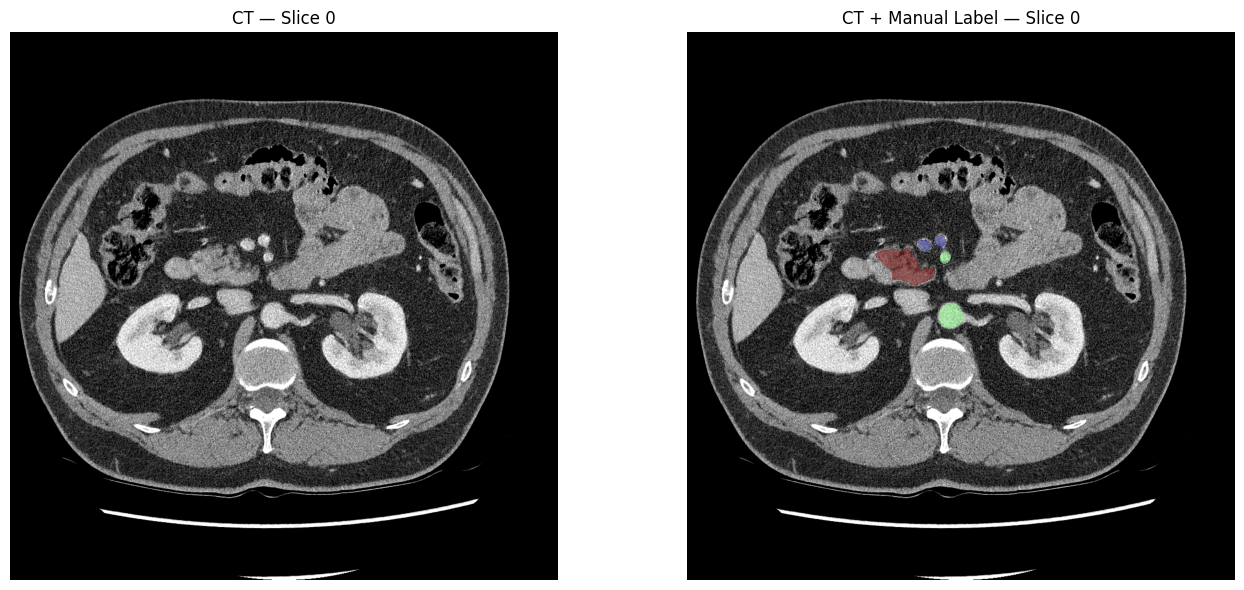

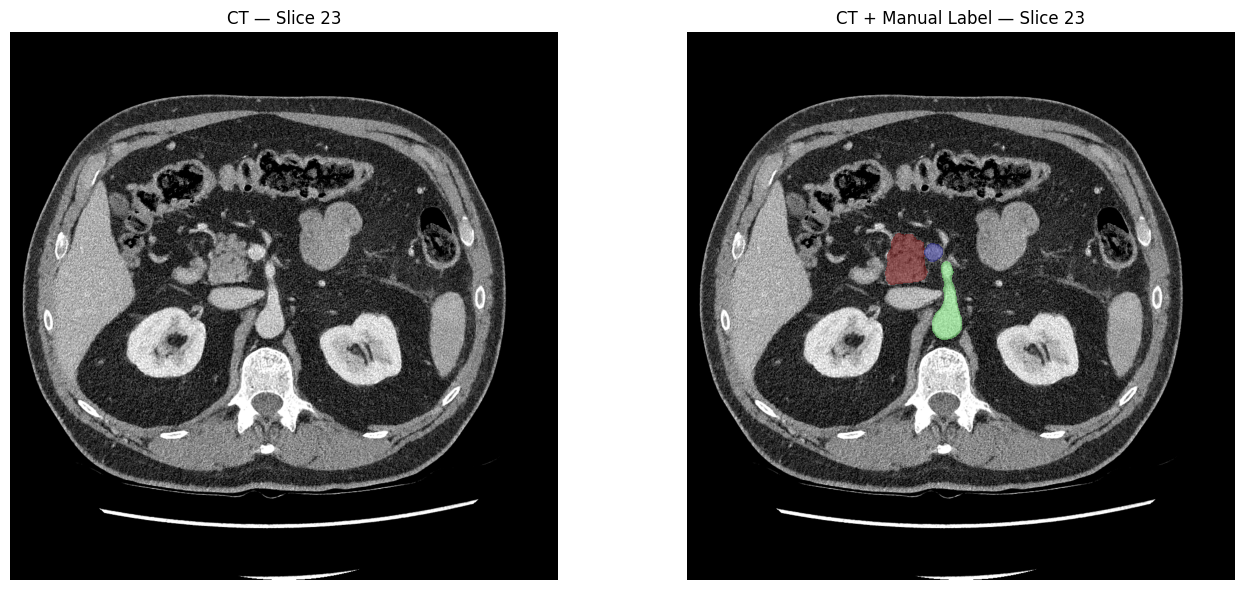

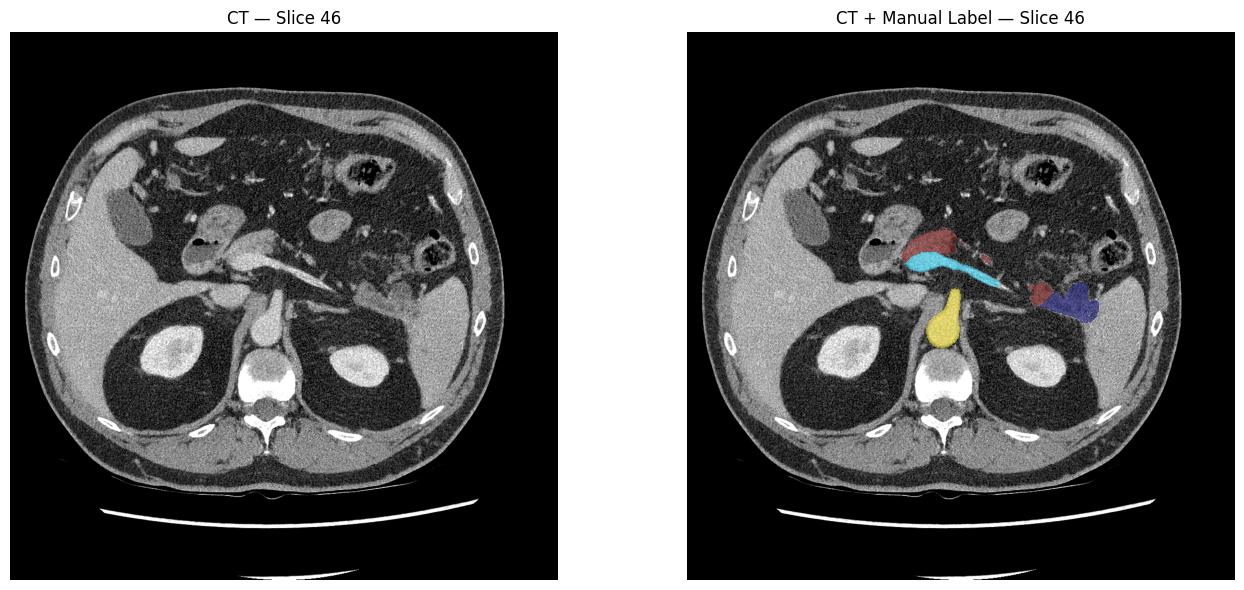

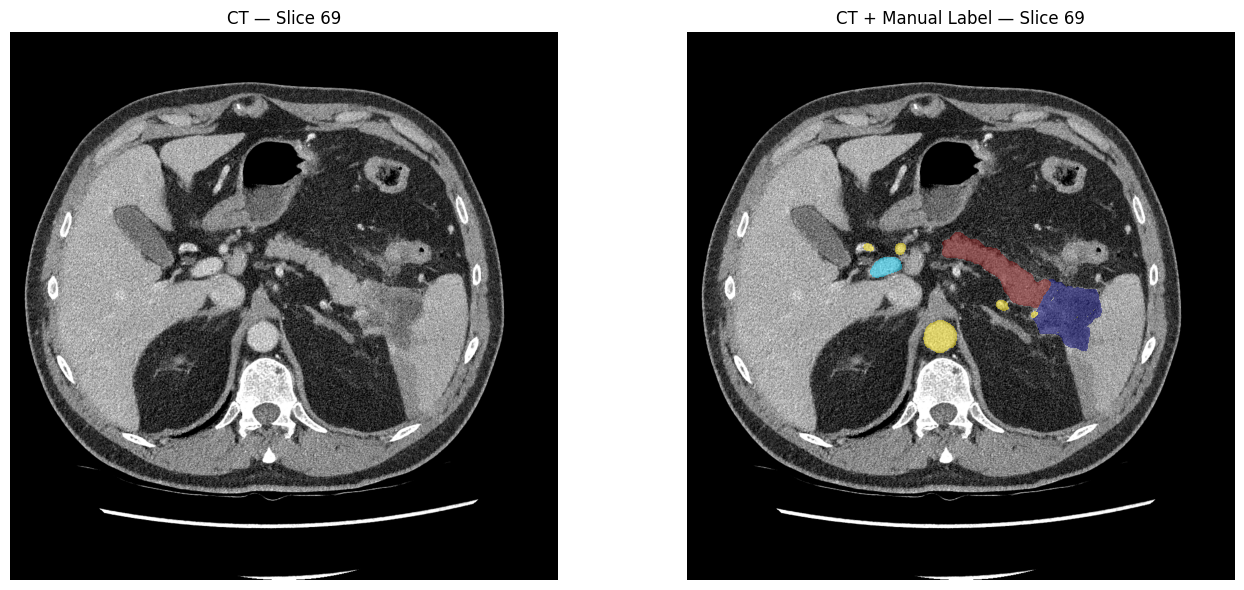

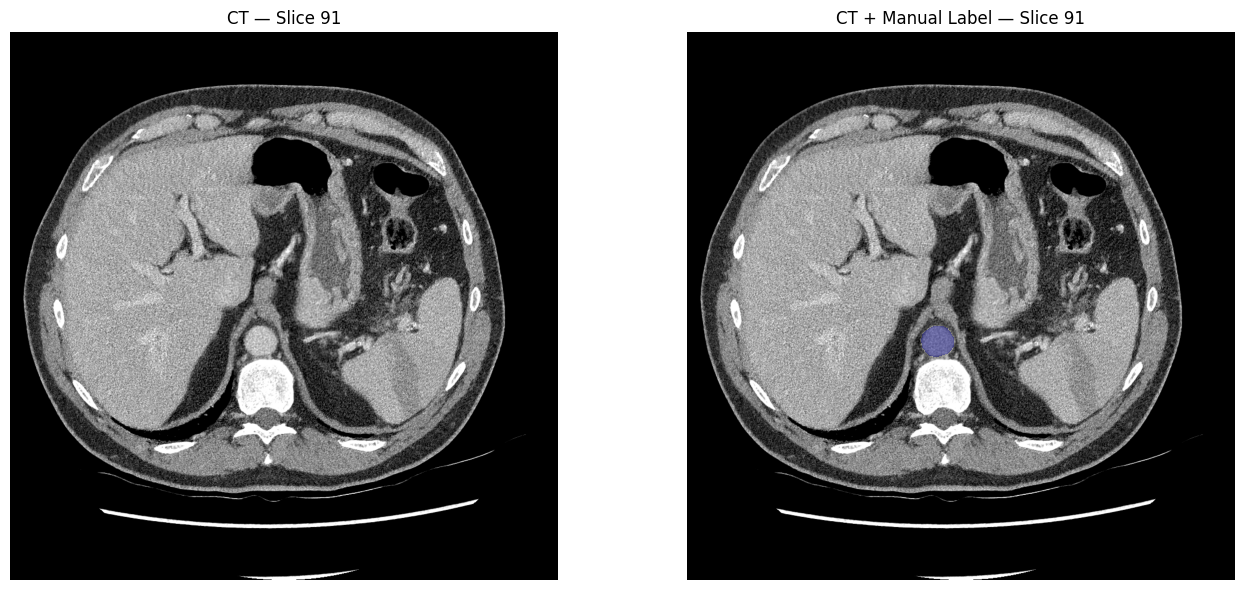


VISUAL INSPECTION COMPLETE


In [31]:
# ============================================================
# CT vs MANUAL LABEL VISUAL INSPECTION
# Case: 100936_00001
# ============================================================

from pathlib import Path

import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# CASE
# ------------------------------------------------------------

study_id = "100936_00001"

PROJECT_ROOT = Path.cwd().parent

ct_path = (
    PROJECT_ROOT
    / "data"
    / "raw_ct"
    / f"{study_id}_0000.nii.gz"
)

label_path = (
    PROJECT_ROOT
    / "data"
    / "labels"
    / "Manual_Labels"
    / f"{study_id}.nii.gz"
)


print("=" * 70)
print(f"VISUAL INSPECTION: {study_id}")
print("=" * 70)

print("\nCT:")
print(ct_path)

print("\nManual label:")
print(label_path)


# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------

ct_image = sitk.ReadImage(str(ct_path))
label_image = sitk.ReadImage(str(label_path))

ct = sitk.GetArrayFromImage(ct_image).astype(np.float32)
label = sitk.GetArrayFromImage(label_image)


# ------------------------------------------------------------
# BASIC INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("IMAGE INFORMATION")
print("=" * 70)

print("\nCT shape:")
print(ct.shape)

print("Label shape:")
print(label.shape)

print("\nCT spacing:")
print(ct_image.GetSpacing())

print("Label spacing:")
print(label_image.GetSpacing())

print("\nCT intensity range:")
print(np.min(ct), "→", np.max(ct))

print("\nCT percentiles:")
print(
    np.percentile(
        ct,
        [1, 5, 50, 95, 99]
    )
)

print("\nLabel values:")
print(np.unique(label))


# ------------------------------------------------------------
# LABELED SLICES
# ------------------------------------------------------------

nonzero_per_slice = np.count_nonzero(
    label,
    axis=(1, 2)
)

labeled_slices = np.where(
    nonzero_per_slice > 0
)[0]


print("\n" + "=" * 70)
print("LABELED SLICE RANGE")
print("=" * 70)

print(f"\nNumber of labeled slices: {len(labeled_slices)}")

if len(labeled_slices) > 0:

    first_slice = int(labeled_slices[0])
    last_slice = int(labeled_slices[-1])

    print(f"First labeled slice: {first_slice}")
    print(f"Last labeled slice : {last_slice}")


# ------------------------------------------------------------
# REPRESENTATIVE SLICES
# ------------------------------------------------------------

if len(labeled_slices) > 0:

    indices = [
        labeled_slices[0],
        labeled_slices[len(labeled_slices) // 4],
        labeled_slices[len(labeled_slices) // 2],
        labeled_slices[
            (3 * len(labeled_slices)) // 4
        ],
        labeled_slices[-1],
    ]

    # Remove duplicates while preserving order
    selected_slices = list(
        dict.fromkeys(
            int(z) for z in indices
        )
    )

else:

    selected_slices = []


# ------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------

if selected_slices:

    # Display CT using a soft-tissue window.
    # This is for visualization only and does NOT modify data.
    window_center = 40
    window_width = 400

    window_min = (
        window_center - window_width / 2
    )

    window_max = (
        window_center + window_width / 2
    )

    ct_display = np.clip(
        ct,
        window_min,
        window_max
    )

    ct_display = (
        ct_display - window_min
    ) / (
        window_max - window_min
    )


    print("\n" + "=" * 70)
    print("DISPLAYING REPRESENTATIVE LABELED SLICES")
    print("=" * 70)

    for z in selected_slices:

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(14, 6)
        )

        # ----------------------------------------------------
        # CT
        # ----------------------------------------------------

        axes[0].imshow(
            ct_display[z],
            cmap="gray"
        )

        axes[0].set_title(
            f"CT — Slice {z}"
        )

        axes[0].axis("off")


        # ----------------------------------------------------
        # CT + LABEL
        # ----------------------------------------------------

        axes[1].imshow(
            ct_display[z],
            cmap="gray"
        )

        # Create transparent label overlay
        mask = label[z] > 0

        if np.any(mask):

            overlay = np.ma.masked_where(
                ~mask,
                label[z]
            )

            axes[1].imshow(
                overlay,
                cmap="jet",
                alpha=0.45,
                interpolation="nearest"
            )

        axes[1].set_title(
            f"CT + Manual Label — Slice {z}"
        )

        axes[1].axis("off")


        plt.tight_layout()
        plt.show()


print("\n" + "=" * 70)
print("VISUAL INSPECTION COMPLETE")
print("=" * 70)

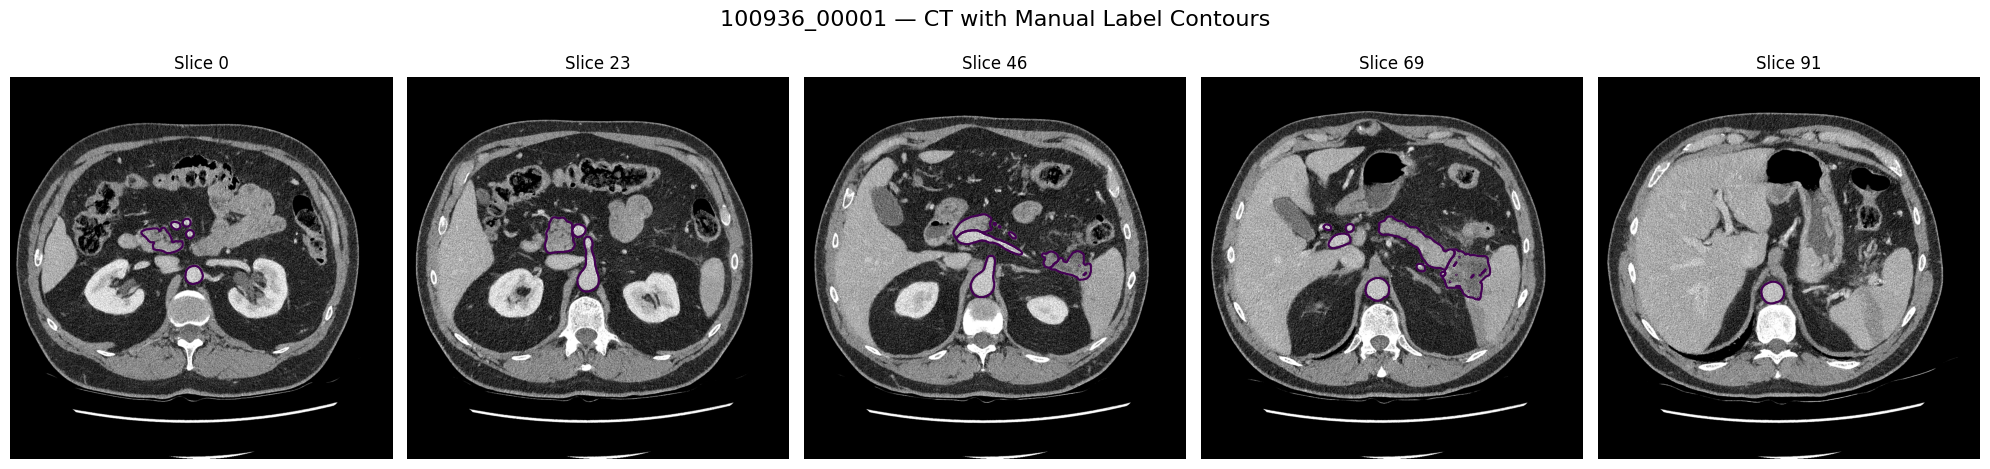

In [32]:
# ============================================================
# 100936_00001 — CT + MANUAL LABEL CONTOUR INSPECTION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Representative labeled slices
selected_slices = [0, 23, 46, 69, 91]

# CT soft-tissue window
window_center = 40
window_width = 400

window_min = window_center - window_width / 2
window_max = window_center + window_width / 2

ct_display = np.clip(
    ct,
    window_min,
    window_max
)

ct_display = (
    ct_display - window_min
) / (window_max - window_min)

fig, axes = plt.subplots(
    1,
    len(selected_slices),
    figsize=(20, 5)
)

for ax, z in zip(axes, selected_slices):

    # CT
    ax.imshow(
        ct_display[z],
        cmap="gray"
    )

    # Label contours
    slice_label = label[z]

    for value in np.unique(slice_label):

        if value == 0:
            continue

        mask = (slice_label == value).astype(float)

        # Draw boundary
        ax.contour(
            mask,
            levels=[0.5],
            linewidths=1.5
        )

    ax.set_title(
        f"Slice {z}"
    )

    ax.axis("off")


fig.suptitle(
    "100936_00001 — CT with Manual Label Contours",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# 100936_00001 — Z-COORDINATE COMPARISON
# ============================================================

import SimpleITK as sitk
from pathlib import Path

study_id = "100936_00001"

PROJECT_ROOT = Path.cwd().parent

ct_path = (
    PROJECT_ROOT
    / "data"
    / "raw_ct"
    / f"{study_id}_0000.nii.gz"
)

label_path = (
    PROJECT_ROOT
    / "data"
    / "labels"
    / "Manual_Labels"
    / f"{study_id}.nii.gz"
)

ct_img = sitk.ReadImage(str(ct_path))
label_img = sitk.ReadImage(str(label_path))

print("=" * 70)
print("Z-COORDINATE COMPARISON")
print("=" * 70)

print("\nCT:")
print("  Origin Z   :", ct_img.GetOrigin()[2])
print("  Spacing Z  :", ct_img.GetSpacing()[2])
print("  Slices     :", ct_img.GetSize()[2])

print("\nManual label:")
print("  Origin Z   :", label_img.GetOrigin()[2])
print("  Spacing Z  :", label_img.GetSpacing()[2])
print("  Slices     :", label_img.GetSize()[2])


print("\n" + "=" * 70)
print("SELECTED SLICE PHYSICAL Z POSITIONS")
print("=" * 70)

for z in [0, 23, 46, 69, 91]:

    ct_z = (
        ct_img.GetOrigin()[2]
        + z * ct_img.GetSpacing()[2]
    )

    label_z = (
        label_img.GetOrigin()[2]
        + z * label_img.GetSpacing()[2]
    )

    print(
        f"\nSlice {z}:"
        f"\n  CT Z      = {ct_z:.3f} mm"
        f"\n  Label Z   = {label_z:.3f} mm"
        f"\n  Difference= {label_z - ct_z:.3f} mm"
    )

print("\n" + "=" * 70)

Z-COORDINATE COMPARISON

CT:
  Origin Z   : 1500.5
  Spacing Z  : 0.7543209791183472
  Slices     : 406

Manual label:
  Origin Z   : 1500.5
  Spacing Z  : 0.5
  Slices     : 406

SELECTED SLICE PHYSICAL Z POSITIONS

Slice 0:
  CT Z      = 1500.500 mm
  Label Z   = 1500.500 mm
  Difference= 0.000 mm

Slice 23:
  CT Z      = 1517.849 mm
  Label Z   = 1512.000 mm
  Difference= -5.849 mm

Slice 46:
  CT Z      = 1535.199 mm
  Label Z   = 1523.500 mm
  Difference= -11.699 mm

Slice 69:
  CT Z      = 1552.548 mm
  Label Z   = 1535.000 mm
  Difference= -17.548 mm

Slice 91:
  CT Z      = 1569.143 mm
  Label Z   = 1546.000 mm
  Difference= -23.143 mm

